# Assigment 4

Consider a square plate with sides [−1,1]×[−1,1]
. At time t = 0 we are heating the plate up such that the temperature is 𝑢=5
 on one side and 𝑢=0
 on the other sides. The temperature evolves according to:

𝑢𝑡=Δ𝑢
.

At what time 𝑡∗
 does the plate reach 𝑢=1
 at the center of the plate?
Implement a finite difference scheme and try with explicit and implicit time-stepping.



In [1]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt

from numba import njit, prange, float64, int64
from numba import cuda

import time

## initialisations

Create plate code and index relevant boundary conditions to compute du/dt = Au for flat u and five point stencil matrix A for Euler forward method.

In [2]:
N = 21

def A_row_indices(N):
    '''
    Compute relevant row indices for dt matrix A account for boundary conditions
    '''
    assert N % 2 == 1, "N must be odd to ensure a definite centre term."
    assert N > 2, "N must be greater than 2 to define a valid grid."

    # Create output template
    rows = np.arange(0,N**2,1)

    # Compute boundary row indices
    LHS_col_indices = np.arange(0, N**2, N)
    RHS_col_indices = np.arange(N - 1, N**2, N)
    Top_row_indices = np.arange(N)
    Bottom_row_indices = np.arange(N**2 - N, N**2)
    boundary_indices = np.unique(np.concatenate((LHS_col_indices, RHS_col_indices, Top_row_indices, Bottom_row_indices)))

    # Remove all matching indices from rows
    rows = np.delete(rows, boundary_indices)

    return rows

indices = A_row_indices(N)
print(indices.dtype)

int64


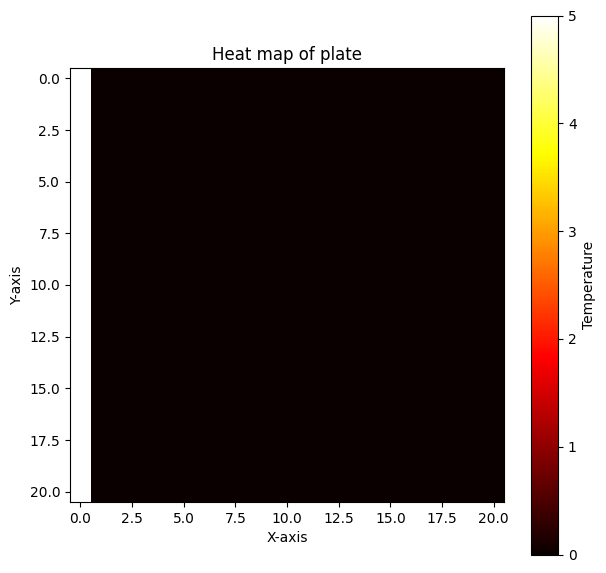

In [2]:
# Plot for intial conditions flat_plate
# Boundary conditions are properly applied :3

def plot_plate(matrix, N):
    """
    Plot the 2D heat map given matrix
    """
    dense_matrix = matrix.reshape(N, N)
    plt.figure(figsize=(7, 7))
    plt.imshow(dense_matrix, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Temperature')
    plt.title('Heat map of plate')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

N = 21
plate = np.zeros(shape = (N,N), dtype = np.float64)
plate[:,0] = 5

plot_plate(plate.flatten(),N)


## CPU iteration

Using above initalisations leveraged Numba to create a time iteration program for plate u cutting off at u centre (index (N//2)*N + (N//2)) >=1

Note assertion on C is a result of the CFL condition and will be explained later.

In [ ]:
@njit(parallel=True)
def time_step(u,indi,c,N):
    """
    Performs one timestep of the 5-point stencil update on the plate.
    """
    v = np.copy(u)
    for row in prange(len(indi)):
        i = indi[row]
        v[i] = u[i] - (4*u[i] - u[i-1] - u[i+1] - u[i-N] - u[i+N]) * c
    return v

def Numba_CPU_timemachine(N, dt, u_start=None, t_start=0.0, sf = 1):
    """
    Simulates the temperature distribution on a plate until the center reaches 1.0.
    """

    # Compute parameters
    h = 2 / (N - 1)  # Spatial step size
    C = ((N - 1)**2 * dt / 4)  # dt/h^2
    assert C <= 0.25, "C must be less than or equal to 1/4 for stability."

    print("CPU_Numba")
    print(f"N: {N}")
    print(f"dt: {dt}")
    print(f"C: {C}")

    # Initialize plate
    if u_start is None:
      plate = np.zeros(shape = (N,N), dtype = np.float64)
      plate[:,0] = 5 * sf
      u = plate.flatten()
    else:
        u = u_start

    indices = A_row_indices(N)
    CI = (N // 2) * N + (N // 2) # Center index

    # Start simulation
    i = 0
    start_time = time.time()

    # Loop until the center reaches at least 1.0
    while u[CI] < 1.0 * sf:
        u = time_step(u, indices, C, N)
        i += 1

        # Print progress every 2000 iterations
        if i % 500 == 0:
            print(f"\rIteration {i}, Centre point u = {u[CI]:.12f}, t = {t_start + i*dt:.12f}",
                  end="", flush=True)

    end_time = time.time()
    runtime = end_time - start_time

    t = t_start + i*dt  # Final time

    print(f"\nFinished at iteration {i}, u_cen: {u[CI]} t: {t:.16f}")
    print(f"Runtime: {runtime:.16f} seconds")

    return {
        "final_state": u,
        "final_time": t,
        "runtime": runtime
    }

Maximum timestep dt is 2.450740123517302e-05:
CPU_Numba
N: 201
dt: 2.5e-05
C: 0.25
Iteration 16500, Centre point u = 0.985430661972, t = 0.412500000000
Finished at iteration 16960, u_cen: 1.0000176929727616 t: 0.4240000000000000
Runtime: 4.5412085056304932 seconds


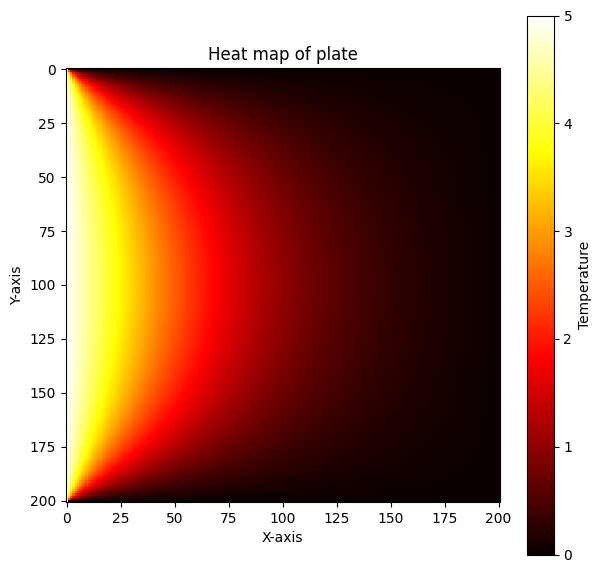

In [ ]:
N = 201
dt = 1/(N-1)**2  #1/(N-1)**2 Largest possible dt while remaining stable
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res = Numba_CPU_timemachine(N, dt)

plot_plate(res['final_state'],N)

## GPU iteration
Using same principal as above implimented a GPU scheme for time evolution facilitating data collection for larger N and smaller time steps (dt).

In [3]:
# Get GPU information
cuda.detect()

Found 1 CUDA devices
id 0    b'NVIDIA A100-SXM4-40GB'                              [SUPPORTED]
                      Compute Capability: 8.0
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-92420371-1f10-dc77-0b29-5ea33bf97b59
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 2
Summary:
	1/1 devices are supported


True

In [4]:
@cuda.jit
def cuda_timestep(u, v, N, c):
    '''
    Performs one timestep of the 5-point stencil update on the plate.
    '''
    i = cuda.grid(1)
    if i < N*N:
        row = i // N
        col = i % N
        # Only update interior points
        if 0 < row < N-1 and 0 < col < N-1:
            v[i] = u[i] - (4*u[i] - u[i-1] - u[i+1] - u[i-N] - u[i+N]) * c
        else:
            # Keep boundary points unchanged
            v[i] = u[i]

def Cuda_GPU_timemachine(N, dt, u_start=None, t_start=0.0, sf = 1):
    """
    Simulates the temperature distribution on a plate until the center reaches 1.0.
    """
    # Compute parameters
    h = 2 / (N - 1)  # Spatial step size
    C = ((N - 1)**2 * dt / 4)  # dt/h**2
    #assert C <= 0.25, "C must be less than or equal to 1/4 for stability."

    print("GPU_Cuda")
    print(f"N : {N}")
    print(f"dt: {dt}")
    print(f"C : {C}")

    # Initialize plate if not provided
    if u_start is None:
      plate = np.zeros(shape = (N,N), dtype = np.float64)
      plate[:,0] = 5
      u = plate.flatten()
    else:
        u = u_start

    # Center index
    CI = (N // 2) * N + (N // 2)  # Center index

    # Create a copy for v
    v = np.copy(u)

    d_u = cuda.to_device(u)
    d_v = cuda.to_device(v)

    threads_per_block = 256
    blocks_per_grid = (N**2 + threads_per_block - 1) // threads_per_block

    start_time = time.time()

    i = 0
    print_interval = 200  # Print and check every 200 iterations
    u_cen = []
    while True:
        # Launch CUDA kernel
        cuda_timestep[blocks_per_grid, threads_per_block](d_u, d_v, N, C)

        # Swap references for next iteration (u <- v, v <- u)
        d_u, d_v = d_v, d_u

        centre_value = d_u[CI]
        u_cen.append(centre_value)

        # Every 'print_interval' steps, synchronize and check center value
        if i % print_interval == 0:
            cuda.synchronize()
            print(f"\rIteration {i}, Centre point u = {centre_value:.12f}, t = {i*dt:.12f}", end="", flush=True)

        i += 1

        if centre_value >= 1.0:
            break

    # Final synchronization
    cuda.synchronize()

    # Copy final result to host
    u_final = d_u.copy_to_host()

    end_time = time.time()
    runtime = end_time - start_time
    t = t_start + i*dt  # Final time
    t_p = t - dt

    print(f"\nFinished at iteration {i}, u_cen: {centre_value} t: {t:.16f}")
    print(f"Runtime: {runtime:.16f} seconds")

    # Construct results dictionary
    results = {
        "final_state": u_final,
        "final_time": t,
        "u_cen": u_cen,
        "runtime": runtime
    }

    return results

Maximum timestep dt is 1.554716699523013e-06:
GPU_Cuda
N : 801
dt: 1.554716699523013e-06
C : 0.24875467192368209
Iteration 272600, Centre point u = 0.999762596360, t = 0.423815772290
Finished at iteration 272725, u_cen: 1.0000004011200954 t: 0.4240101118774137
Runtime: 44.2816879749298096 seconds


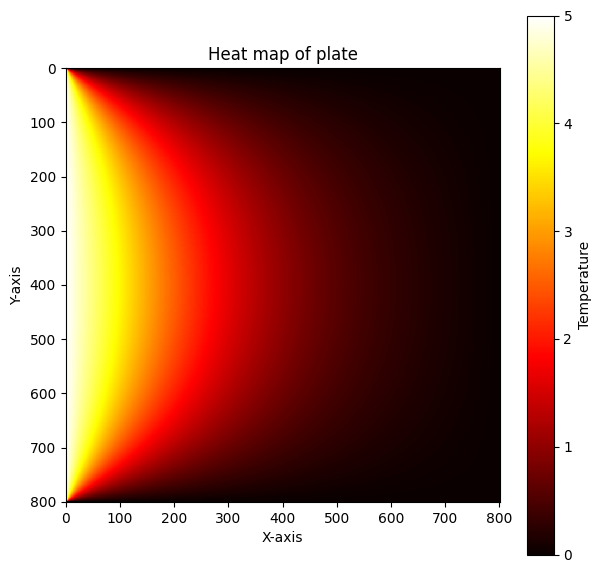

In [ ]:
N = 801
dt = 1/(N+1)**2  #1/(N-1)**2 Largest possible dt while remaining stable
print(f"Maximum timestep dt is {1/(N+1)**2}:")

resC = Cuda_GPU_timemachine(N, dt)
plot_plate(resC['final_state'],N)

In [ ]:
print(resC["u_cen"][-20:])
print(np.dtype(resC["u_cen"][0]))

[0.9999639779237239, 0.9999658950660221, 0.9999678121936578, 0.9999697293066296, 0.9999716464049394, 0.9999735634885855, 0.9999754805575692, 0.9999773976118901, 0.9999793146515487, 0.9999812316765446, 0.9999831486868783, 0.9999850656825499, 0.9999869826635591, 0.9999888996299066, 0.999990816581592, 0.9999927335186158, 0.9999946504409777, 0.9999965673486785, 0.9999984842417174, 1.0000004011200954]
float64


## Numeric investigation on stability
Stability of the numerical scheme is largely dependent on the chosen time step relative to the Courant-Friedrichs-Lewy (CFL) condition, which ensures convergence of the iterative solution. To test the stability of the scheme, I will use a series of simulations with time steps dt set at, below, and slightly above the Courant limit, dt_c =  By observing the behavior of the solution, such as whether it remains bounded or diverges, I can evaluate the impact of dt on stability, identifying dt/h^2 ≤ 1/4 as the CFL condition, giving
dt_c/h^2 = 1/4 as the maximum dt, from which dt_c = 1/(N+1)^2 can be pulled via
h = 2/(N-1).

Further, from condition we can see that dt/h^2 a useful value dubbed C in the time step calculation and also the Courant number should never exceed 0.25 which can be seen in above calculations.


In [ ]:
N = 201
dt_c = 1/(N+1)**2
dt_list = np.arange(0.95,1.06,0.01,dtype = np.float64)

for i in range(len(dt_list)):
    dt = dt_list[i]*dt_c
    print(f"dt = {dt_list[i]}*dt_c \n")
    resCNI = Cuda_GPU_timemachine(N, dt)
    print('\n')


dt = 0.95*dt_c 

GPU_Cuda
N : 201
dt: 2.328203117341437e-05
C : 0.2328203117341437
Iteration 18200, Centre point u = 0.999714782404, t = 0.423732967356
Finished at iteration 18211, u_cen: 1.0000020082790215 t: 0.4239890696990491
Runtime: 2.9761984348297119 seconds


dt = 0.96*dt_c 

GPU_Cuda
N : 201
dt: 2.35271051857661e-05
C : 0.235271051857661
Iteration 18000, Centre point u = 0.999412702171, t = 0.423487893344
Finished at iteration 18022, u_cen: 1.0000225679940935 t: 0.4240054896578767
Runtime: 2.9968037605285645 seconds


dt = 0.97*dt_c 

GPU_Cuda
N : 201
dt: 2.377217919811783e-05
C : 0.2377217919811783
Iteration 17800, Centre point u = 0.998988930452, t = 0.423144789726
Finished at iteration 17836, u_cen: 1.000016840168251 t: 0.4240005881776296
Runtime: 2.9076206684112549 seconds


dt = 0.98*dt_c 

GPU_Cuda
N : 201
dt: 2.401725321046956e-05
C : 0.2401725321046956
Iteration 17600, Centre point u = 0.998442852580, t = 0.422703656504
Finished at iteration 17654, u_cen: 1.000017155321

The data demonstrates that the stability of our explicit scheme strongly depends on the time step dt relative to the Courant limit dt_c. As seen when  dt > 1.02 dt_c, the scheme becomes unstable with significant divergence, worsening as dt increases.

This instability from the Courant number. Representing the ratio of the physical distance a wave travels in one time step to the spatial resolution of the grid. This ratio is important as if the Courant number exceeds the threshold maximum, information effectively jumps across grid points invalidating the scheme's ability to
effectively solve the problem.

## Plotting scheme convergence towards t_ideal=0.424011387033
Due to the choice of an odd N, where N is the total number of spatial points per axis, the grid inherently has a well-defined center. This reduces the sensitivity of the results to N, as demonstrated by N=7, which provides suprsingly accurate results up to 4 decimal places small enough timestep. Therefore, for this convergence plot, I will again use N=201 which does not affect the accuracy of my desiered dts. Further, the overall precision of the iterative method is fundamentally limited by the lowest decimal place in dt as well as the accuracy being constrained by the largest highest decimal place in dt, also as a consequence of the iterative approach forcing us to choose between precision and runtime. Under this regime the runtime must increase tenfold for each digit of precision. Using the below data where this pattern is apparent, assuming no error from N size calulaing to a prescion of 10^-12 would simply be an exercise in patience lasting roughly 2 years.

In [ ]:
N = 7
dt = 1e-6  #1/(N-1)**2 Largest possible dt while remaining stable
print(f"Maximum timestep dt is {1/(N+1)**2}:")

resCN7 = Cuda_GPU_timemachine(N, dt)

Maximum timestep dt is 0.015625:
GPU_Cuda
N : 7
dt: 1e-06
C : 9e-06
Iteration 1200, Centre point u = 0.000001032945, t = 0.001200000000

/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Iteration 424000, Centre point u = 0.999897674674, t = 0.424000000000
Finished at iteration 424087, u_cen: 1.0000011504444193 t: 0.4240870000000000
Runtime: 69.5553977489471436 seconds


In [ ]:
N = 201
t_ideal = 0.424011387033
dt_list = [1/(N+1)**2,1e-5,1e-6]
times = []

for i in range(len(dt_list)):
    import time as time # Band-aid solution
    dt = dt_list[i]
    print(f"dt = {dt_list[i]} \n")

    resCPS = Cuda_GPU_timemachine(N, dt)
    time = resCPS['final_time']

    times.append(time)
    print('\n')

dt = 2.450740123517302e-05 

GPU_Cuda
N : 201
dt: 2.450740123517302e-05
C : 0.2450740123517302
Iteration 17200, Centre point u = 0.996980426199, t = 0.421527301245
Finished at iteration 17301, u_cen: 1.0000202028312462 t: 0.4240025487697284
Runtime: 2.8227803707122803 seconds


dt = 1e-05 

GPU_Cuda
N : 201
dt: 1e-05
C : 0.1
Iteration 42400, Centre point u = 1.000010734049, t = 0.424000000000
Finished at iteration 42401, u_cen: 1.000010734048901 t: 0.4240100000000001
Runtime: 6.7938530445098877 seconds


dt = 1e-06 

GPU_Cuda
N : 201
dt: 1e-06
C : 0.01
Iteration 424000, Centre point u = 0.999988064628, t = 0.424000000000
Finished at iteration 424011, u_cen: 1.0000003940578899 t: 0.4240110000000000
Runtime: 68.5251698493957520 seconds




Text(0, 0.5, 'Relative error')

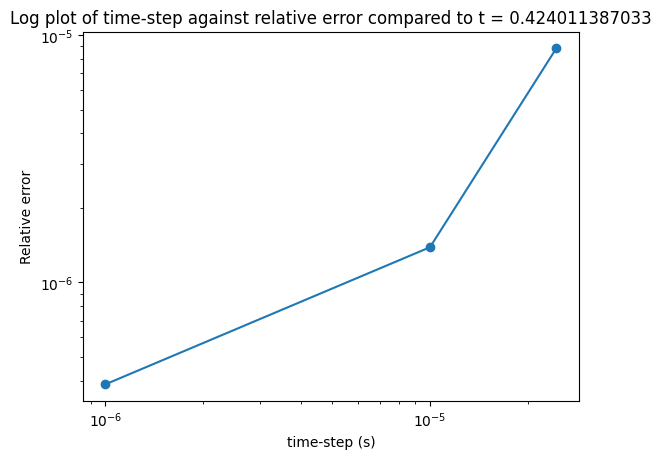

In [ ]:
# Plot results
diffs = np.zeros(len(times))
for i in range(len(times)):
    diffs[i] = t_ideal - times[i]

plt.title('Log plot of time-step against relative error compared to t = 0.424011387033')
plt.plot(dt_list, diffs, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time-step (s)')
plt.ylabel('Relative error')

To further explore my hypothesis above I created a plot of the relative time error wrt N, using the largest and thus fastest dt to compute the simulation. From the data collected we can confrim that runtime and overall precision are roughly in line with previously obtained dt results which remais the main obstacle in precision. Interestingly however, is the lack of effect on runtime from increased N, most likely due to the GPU optimisations and five point stencil scheme used to simulate what would have been an N**2 by N**2 sparse matrix A.

Investigating wrt N using largest dt for relevant N gives the

---

following.

In [ ]:
N_list = np.array([101,201,401,801,1001])
times = []

for i in range(len(N_list)):
    import time as time # Band-aid solution
    N = N_list[i]
    print(f"N = {N_list[i]} \n")

    resCPSN = Cuda_GPU_timemachine(N, 1/(N+1)**2)

    time = resCPSN['final_time']
    times.append(time)
    print('\n')

N = 101 

GPU_Cuda
N : 101
dt: 9.611687812379854e-05
C : 0.24029219530949636
Iteration 1200, Centre point u = 0.180206217516, t = 0.115340253749

/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Iteration 4400, Centre point u = 0.998885116865, t = 0.422914263745
Finished at iteration 4411, u_cen: 1.0000728261594711 t: 0.4239715494040754
Runtime: 0.7154474258422852 seconds


N = 201 

GPU_Cuda
N : 201
dt: 2.450740123517302e-05
C : 0.2450740123517302
Iteration 17200, Centre point u = 0.996980426199, t = 0.421527301245
Finished at iteration 17301, u_cen: 1.0000202028312462 t: 0.4240025487697284
Runtime: 2.7942295074462891 seconds


N = 401 

GPU_Cuda
N : 401
dt: 6.187965644414742e-06
C : 0.2475186257765897
Iteration 68400, Centre point u = 0.999083504607, t = 0.423256850078
Finished at iteration 68521, u_cen: 1.0000007109652709 t: 0.4240055939209426
Runtime: 11.0573043823242188 seconds


N = 801 

GPU_Cuda
N : 801
dt: 1.554716699523013e-06
C : 0.24875467192368209
Iteration 272600, Centre point u = 0.999762596360, t = 0.423815772290
Finished at iteration 272725, u_cen: 1.0000004011200954 t: 0.4240101118774137
Runtime: 44.8783705234527588 seconds


N = 1001 

GPU_Cuda
N : 1001
dt: 

Text(0, 0.5, 'Relative error')

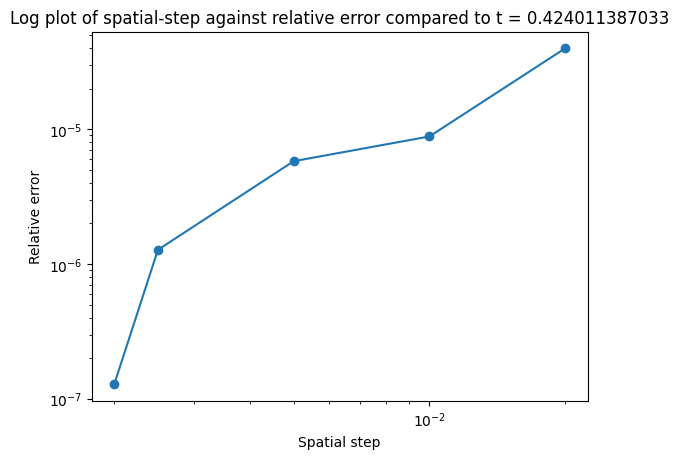

In [ ]:
# Plot results
Ndiffs = np.zeros(len(times))
for i in range(len(times)):
    Ndiffs[i] = t_ideal - times[i]

plt.title('Log plot of spatial-step against relative error compared to t = 0.424011387033')
plt.plot(2/(N_list-1), Ndiffs, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Spatial step')
plt.ylabel('Relative error')

Maximum timestep dt is 9.960119680798084e-07:
GPU_Cuda
N : 1001
dt: 1e-07
C : 0.024999999999999998
Iteration 4240000, Centre point u = 0.999986195408, t = 0.424000000000
Finished at iteration 4240113, u_cen: 1.0000000046844095 t: 0.4240113000000000
Runtime: 673.0837378501892090 seconds


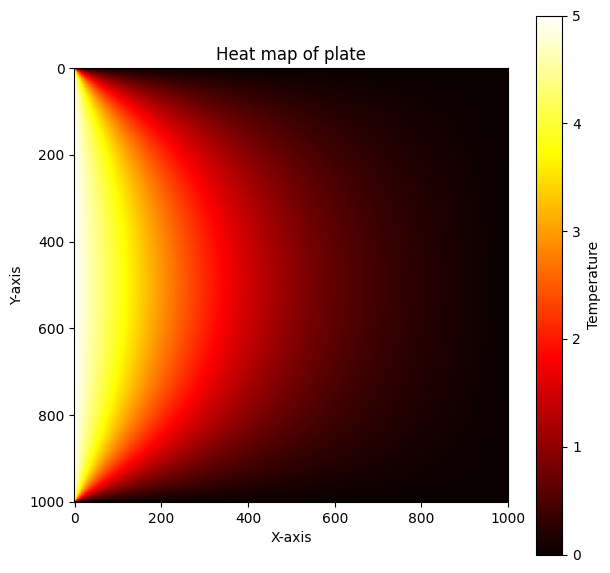

In [ ]:
# Attempt at 7d.p. prescision
import time as time # Band-aid solution
N = 1001
dt = 1e-7
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res7dp = Cuda_GPU_timemachine(N, dt)
plot_plate(res7dp['final_state'],N)

Maximum timestep dt is 2.495007490012485e-07:
GPU_Cuda
N : 2001
dt: 1e-08
C : 0.01
Iteration 42401000, Centre point u = 0.999998310925, t = 0.424010000000
Finished at iteration 42401138, u_cen: 1.0000000000549927 t: 0.4240113800000000
Runtime: 7128.8768966197967529 seconds


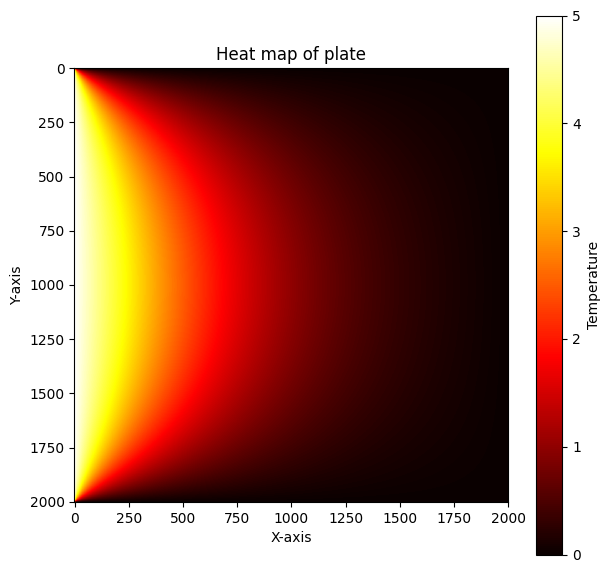

In [7]:
# 8d.p
import time as time # Band-aid solution
N = 2001
dt = 1e-8
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res8dp = Cuda_GPU_timemachine(N, dt)
plot_plate(res8dp['final_state'],N)

In [5]:
# 9d.p
import time as time # Band-aid solution
N = 2001
dt = 1e-9
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res9dp = Cuda_GPU_timemachine(N, dt)
plot_plate(res8dp['final_state'],N)

Maximum timestep dt is 2.495007490012485e-07:
GPU_Cuda
N : 2001
dt: 1e-09
C : 0.001
Iteration 12719400, Centre point u = 0.000000001812, t = 0.012719400000

KeyboardInterrupt: 

Maximum timestep dt is 2.495007490012485e-07:
GPU_Cuda
N : 2001
dt: 4.24011387033e-08
C : 0.0424011387033
Iteration 9999800, Centre point u = 0.999989646845, t = 0.424002906805
Finished at iteration 10000000, u_cen: 1.0000000503744388 t: 0.4240113870330000
Runtime: 1627.8613033294677734 seconds


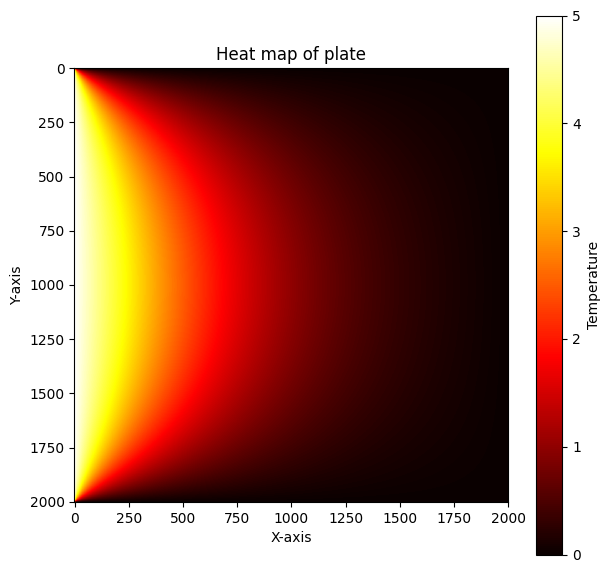

In [6]:
# Matrix error test.
import time as time # Band-aid solution
t_ideal = 0.424011387033
N = 2001
dt = t_ideal/1e7
print(f"Maximum timestep dt is {1/(N+1)**2}:")

resCTC = Cuda_GPU_timemachine(N, dt)
plot_plate(resCTC['final_state'],N)